In [ ]:
pip install gymnasium

In [ ]:
import gymnasium as gym

In [ ]:
env = gym.make("CartPole-v1", render_mode="human")

In [ ]:
observation, info = env.reset()

In [ ]:
for step in range(1000):
    env.render()  # Optional: visual rendering
    action = env.action_space.sample()  # Random policy
    observation, reward, done, truncated, info = env.step(action)

    if done or truncated:
        print("Episode finished. Restarting...")
        observation, info = env.reset()

env.close()

Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode finished. Restarting...
Episode 

In [ ]:
print("Observation space:", env.observation_space)
print("Action space:", env.action_space)

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)


Value Function under Fixed Policy:
[[ -1.3906558  -0.434062  -10.          1.8098      3.122    ]
 [ -0.434062    0.62882   -10.          3.122       4.58     ]
 [  0.62882     1.8098    -10.          4.58        6.2      ]
 [  1.8098      3.122       4.58        6.2         8.       ]
 [  3.122       4.58        6.2         8.         10.       ]]


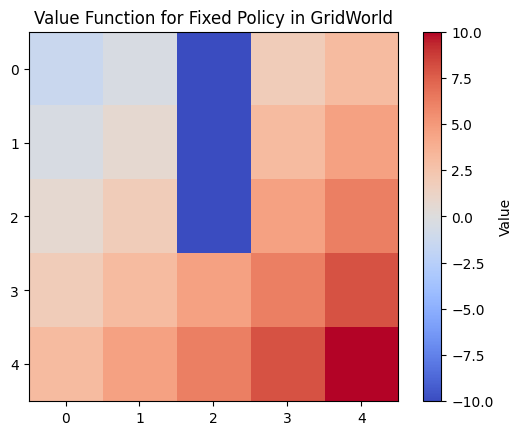

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# GridWorld parameters
N = 5
gamma = 0.9
goal = (4, 4)
pit = (2, 2)

# Rewards
def reward(s):
    if s == goal:
        return 10
    elif s == pit:
        return -10
    else:
        return -1

# Fixed policy: move Right if possible, else Down
def policy(state):
    x, y = state
    if x < N - 1:   # Prefer Right
        return (x + 1, y)
    elif y < N - 1: # Otherwise Down
        return (x, y + 1)
    else:
        return (x, y)  # Terminal stays

# Initialize Value Function
V = np.zeros((N, N))

# Iterative Policy Evaluation
theta = 1e-6
while True:
    delta = 0
    for i in range(N):
        for j in range(N):
            s = (i, j)
            v = V[i, j]
            if s == goal or s == pit:
                V[i, j] = reward(s)  # Terminal states
            else:
                s_next = policy(s)
                V[i, j] = reward(s) + gamma * V[s_next]
            delta = max(delta, abs(v - V[i, j]))
    if delta < theta:
        break

print("Value Function under Fixed Policy:")
print(V)

# Visualization
plt.imshow(V, cmap="coolwarm", interpolation="nearest")
plt.colorbar(label="Value")
plt.title("Value Function for Fixed Policy in GridWorld")
plt.show()
